In [1]:
import sys

sys.path.append("..")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from src.utils import (
    set_seed,
    train_model,
    plot_training_history,
    get_device,
    test_model,
    get_report,
    plot_confusion_matrix,
)
from src.data import data_preparation

In [2]:
set_seed()
train_loader, val_loader, test_loader = data_preparation()

Model saved to /Users/aaron/USYD/Research Pathway/models/100_2_remove_encoder.pkl
Model saved to /Users/aaron/USYD/Research Pathway/models/100_2_remove_scaler.pkl


In [3]:
class CNNBlock(nn.Module):
    def __init__(
        self, in_channels, out_channels, kernel_size, stride=1, padding=0, alpha=0.01
    ):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.leaky_relu = nn.LeakyReLU(negative_slope=alpha)
        g = torch.Generator().manual_seed(42)
        nn.init.kaiming_normal_(
            self.conv.weight,
            a=alpha,
            mode="fan_in",
            nonlinearity="leaky_relu",
            generator=g,
        )
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        return self.leaky_relu(self.conv(x))

In [4]:
class CNNClassifier(nn.Module):
    def __init__(self, input_channels=12, num_classes=2, alpha=0.01):
        super(CNNClassifier, self).__init__()
        self.conv_block = nn.Sequential(
            CNNBlock(
                input_channels, 16, kernel_size=5, stride=2, padding=2, alpha=alpha
            ),
            CNNBlock(16, 20, kernel_size=5, stride=2, padding=2, alpha=alpha),
            CNNBlock(20, 24, kernel_size=3, stride=2, padding=1, alpha=alpha),
            CNNBlock(24, 28, kernel_size=3, stride=2, padding=1, alpha=alpha),
            CNNBlock(28, 32, kernel_size=3, stride=2, padding=1, alpha=alpha),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv_block(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = F.softmax(x, dim=1)
        return x

Training:  98%|█████████▊| 49/50 [00:25<00:00,  1.93it/s]

Early stopping triggered after epoch 50


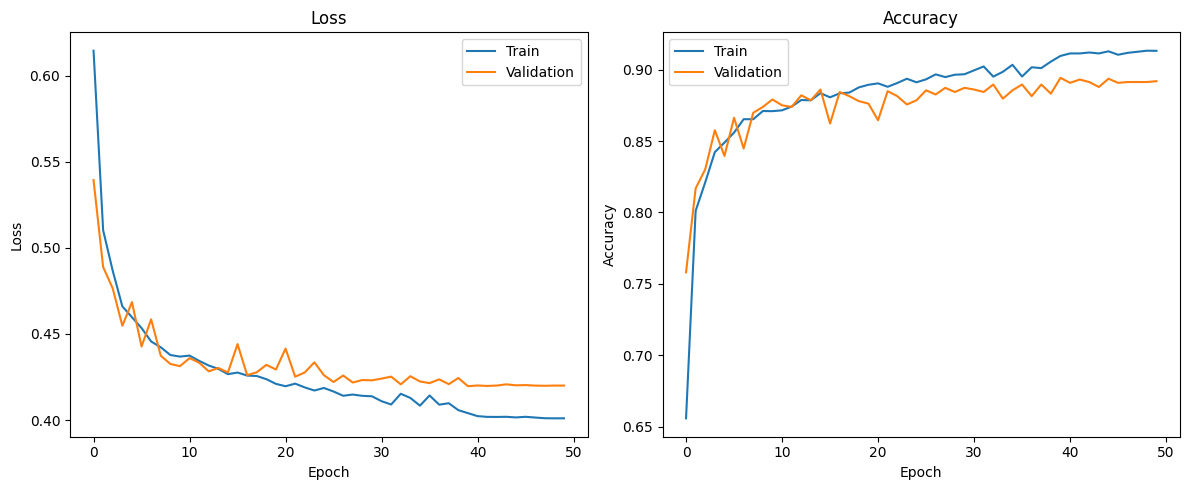

In [5]:
device = get_device()
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, "min", patience=5, factor=0.1
)
model, history = train_model(
    device, model, train_loader, val_loader, optimizer, criterion, scheduler=scheduler
)
fig = plot_training_history(history)

In [6]:
true_labels, predictions = test_model(device, model, test_loader)
cm = get_report(true_labels, predictions)

Testing: 100%|██████████| 14/14 [00:00<00:00, 120.66it/s]

Test Accuracy: 0.8906

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91      2042
         1.0       0.85      0.88      0.87      1376

    accuracy                           0.89      3418
   macro avg       0.89      0.89      0.89      3418
weighted avg       0.89      0.89      0.89      3418



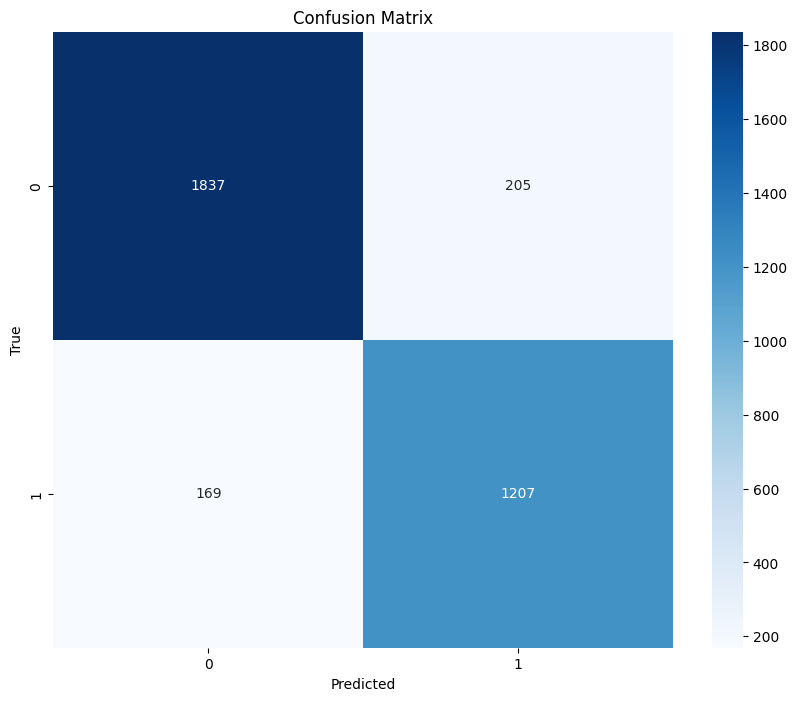

In [7]:
fig = plot_confusion_matrix(cm, 2)